# **Rice Leaf Disease Prediction**

Rice is a staple food for a large portion of the world’s population, and diseases affecting rice plants can cause significant yield losses. Early detection of rice leaf diseases is crucial for effective disease management and sustainable crop production.

This project focuses on building and evaluating convolutional neural network (CNN) models to automatically classify rice leaf images into 3 different disease categories :
- **Bacterialblight** – A bacterial infection in rice leaves causing lesions and yellowing.
- **Leafsmut** – A fungal disease that produces black, powdery spores on leaves.
- **Brownspot** – A common rice leaf disease causing brown lesions on the leaf surface.

# Load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Local
# BASE_DIR = 'Dataset/Train_val'
# BASE_DIR_TEST = 'Dataset'/Test
#collab
BASE_DIR = '/content/drive/MyDrive/Rice leaf/Rice Leaf Diseases Dataset/Train_val/'
BASE_DIR_TEST = '/content/drive/MyDrive/Rice leaf/Rice Leaf Diseases Dataset/Test/'

import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import logging
logging.getLogger('absl').setLevel(logging.ERROR)



# Libraries

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization,Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.applications import VGG16, MobileNetV2,EfficientNetB0
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import math
from PIL import Image
import hashlib
from tensorflow.keras.models import load_model


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:

print("🔍 Checking GPU availability...")
print("TensorFlow version:", tf.__version__)
print("GPU devices available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU IS ACTIVE AND BEING USED!")
    gpu_name = tf.test.gpu_device_name()
    print(f"GPU device name: {gpu_name}")

else:
    print("❌ NO GPU DETECTED - Running on CPU")

🔍 Checking GPU availability...
TensorFlow version: 2.19.0
GPU devices available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU IS ACTIVE AND BEING USED!
GPU device name: /device:GPU:0


# Dataset Link

In [5]:
DATASET_SOURCE = "Mendeley Data: https://data.mendeley.com/datasets/dwtn3c6w6p/1"
DATASET_LICENSE = "CC BY 4.0"

print(f"Dataset Source: {DATASET_SOURCE}")
print(f"License: {DATASET_LICENSE}")


classes = os.listdir(BASE_DIR)
print("Classes:", classes)


Dataset Source: Mendeley Data: https://data.mendeley.com/datasets/dwtn3c6w6p/1
License: CC BY 4.0
Classes: ['Brownspot', 'Bacterialblight', 'Leafsmut']


# Data Preprocessing

In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
datagen_trainval = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    validation_split=0.15
)

train_gen = datagen_trainval.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

val_gen = datagen_trainval.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    BASE_DIR_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 2479 images belonging to 3 classes.
Found 436 images belonging to 3 classes.
Found 571 images belonging to 3 classes.


# Models

# Best Model Prediction

18/18 ━━━━━━━━━━━━━━━━━━━━ 136s 7s/step
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Classification Report:
                  precision    recall  f1-score   support

Bacterialblight       0.95      0.99      0.97       169
      Brownspot       0.99      0.99      0.99       203
       Leafsmut       0.99      0.95      0.97       199

       accuracy                           0.98       571
      macro avg       0.98      0.98      0.98       571
   weighted avg       0.98      0.98      0.98       571



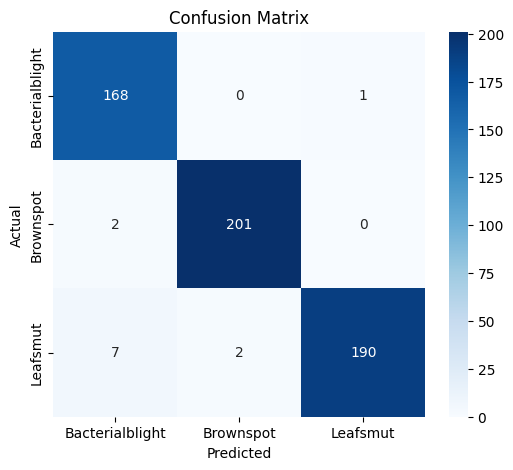

In [7]:
best_model = load_model('/content/drive/MyDrive/Rice leaf/Best Model/mobilenet_trained.h5')

steps = int(np.ceil(test_gen.samples / BATCH_SIZE))

preds = best_model.predict(test_gen, steps=steps)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())
print("Classes:", class_names)


report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
